# 08 — Random Forest
Walk-forward Random Forest on weekly silver log-returns with lagged features.
Same train/val/test split and evaluation metrics as the ARIMA, LSTM, and XGBoost notebooks.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from itertools import product
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load features

In [22]:
train = pd.read_csv('../../data/processed/train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv('../../data/processed/val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv('../../data/processed/test.csv',  index_col=0, parse_dates=True)

TARGET = 'silver_return'
EXOG   = ['gold_return', 'usd_return', 'copper_return', 'sp500_return',
          'vix_return', 'oil_return']

agg = {TARGET: 'sum'}
for c in EXOG:
    agg[c] = 'sum'

def to_weekly(df):
    cols = [c for c in agg.keys() if c in df.columns]
    return df[cols].resample('W-FRI').agg({c: agg[c] for c in cols}).dropna()

train_w = to_weekly(train)
val_w   = to_weekly(val)
test_w  = to_weekly(test)

all_w   = pd.concat([train_w, val_w, test_w])
n_train = len(train_w) + len(val_w)

print(f'Weekly obs — train+val: {n_train}, test: {len(test_w)}')
print(f'Features available: {[c for c in EXOG if c in all_w.columns]}')

Weekly obs — train+val: 417, test: 175
Features available: ['gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return']


## 2. Feature matrix

Each row is week $t$; features are week $t-1$ values so there is no lookahead.
Lags 2 and 3 of silver return give the model a short memory window.

In [23]:
def build_features(df):
    X = pd.DataFrame(index=df.index)
    for col in [c for c in EXOG if c in df.columns]:
        X[f'{col}_lag1'] = df[col].shift(1)
    for lag in [1, 2, 3]:
        X[f'silver_lag{lag}'] = df[TARGET].shift(lag)
    return X

features_all = build_features(all_w)
feature_cols = features_all.columns.tolist()
print('Features:', feature_cols)

Features: ['gold_return_lag1', 'usd_return_lag1', 'copper_return_lag1', 'sp500_return_lag1', 'vix_return_lag1', 'oil_return_lag1', 'silver_lag1', 'silver_lag2', 'silver_lag3']


## 3. Hyperparameter tuning with TimeSeriesSplit

Grid search on the training set only using 5-fold time-series cross-validation.
`TimeSeriesSplit` always trains on past data and validates on future data — no lookahead.

In [24]:
X_tr = features_all.iloc[:n_train][feature_cols].values
y_tr = all_w[TARGET].iloc[:n_train].values

mask = ~np.isnan(X_tr).any(axis=1)
X_tr, y_tr = X_tr[mask], y_tr[mask]

param_grid = {
    'n_estimators':   [100, 200],
    'max_depth':      [6, 8, None],   # None = fully grown trees (RF default)
    'min_samples_leaf': [3, 5, 10],
    'max_features':   ['sqrt', 0.7],
}

tscv = TimeSeriesSplit(n_splits=5)
best_rmse, best_params = np.inf, {}

keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f'Searching {len(combos)} combinations...')

for combo in combos:
    params = dict(zip(keys, combo))
    fold_rmses = []
    for fold_tr, fold_val in tscv.split(X_tr):
        m = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
        m.fit(X_tr[fold_tr], y_tr[fold_tr])
        preds = m.predict(X_tr[fold_val])
        fold_rmses.append(np.sqrt(mean_squared_error(y_tr[fold_val], preds)))
    rmse = np.mean(fold_rmses)
    if rmse < best_rmse:
        best_rmse, best_params = rmse, params

print(f'Best CV RMSE: {best_rmse:.5f}')
print(f'Best params:  {best_params}')

Searching 36 combinations...
Best CV RMSE: 0.03842
Best params:  {'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}


## 4. Walk-forward forecast

Retrains every 4 weeks (monthly) rather than every week — RF with 200 trees changes
negligibly from one extra observation, so weekly retraining is just wasted compute.

In [25]:
def walk_forward(all_w, features_all, n_train, feature_cols,
                 retrain_every=4, window=None, **rf_kwargs):
    """window=None → expanding; window=N → rolling (last N weeks)."""
    y_all = all_w[TARGET].values
    X_all = features_all[feature_cols].values
    preds = np.full(len(all_w) - n_train, np.nan)
    model = None

    for i, t in enumerate(range(n_train, len(all_w))):
        start = max(0, t - window) if window else 0
        X_tr  = X_all[start:t]
        y_tr  = y_all[start:t]
        X_te  = X_all[t:t+1]
        mask  = ~np.isnan(X_tr).any(axis=1)
        if mask.sum() < 10 or np.isnan(X_te).any():
            continue
        if model is None or i % retrain_every == 0:
            model = RandomForestRegressor(random_state=42, n_jobs=-1, **rf_kwargs)
            model.fit(X_tr[mask], y_tr[mask])
        preds[i] = model.predict(X_te)[0]

    return preds

print('Running walk-forward Random Forest — expanding window...')
preds_rf_exp = walk_forward(all_w, features_all, n_train, feature_cols, **best_params)
print('Running walk-forward Random Forest — rolling window (100 weeks)...')
preds_rf_rol = walk_forward(all_w, features_all, n_train, feature_cols, window=100, **best_params)
print('Done')
preds_rf = preds_rf_exp  # default used downstream

Running walk-forward Random Forest — expanding window...
Running walk-forward Random Forest — rolling window (100 weeks)...
Done


## 5. Evaluate

In [26]:
y_test     = all_w[TARGET].iloc[n_train:].values
test_index = all_w.index[n_train:]

def evaluate(name, y_true, y_pred):
    mask = ~np.isnan(y_pred) & ~np.isnan(y_true)
    if mask.sum() == 0:
        print(f'{name:40s}  No valid predictions')
        return None
    y_t, y_p = y_true[mask], y_pred[mask]
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae  = mean_absolute_error(y_t, y_p)
    da   = np.mean(np.sign(y_t) == np.sign(y_p))
    wda  = np.sum(np.abs(y_t) * (np.sign(y_t) == np.sign(y_p))) / np.sum(np.abs(y_t))
    print(f'{name:40s}  RMSE={rmse:.5f}  MAE={mae:.5f}  DA={da:.3f}  WDA={wda:.3f}')
    return {'model': name, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda}

naive_pred = all_w[TARGET].iloc[n_train-1:-1].values

metrics = []
metrics.append(evaluate('Naive (t-1 week)',    y_test[1:], naive_pred[1:]))
metrics.append(evaluate('RF expanding',      y_test, preds_rf_exp))
metrics.append(evaluate('RF rolling (100w)', y_test, preds_rf_rol))

metrics_df = pd.DataFrame([m for m in metrics if m is not None])
metrics_df.to_csv('../../data/processed/metrics_rf.csv', index=False)
metrics_df

Naive (t-1 week)                          RMSE=0.07584  MAE=0.05386  DA=0.494  WDA=0.491
RF expanding                              RMSE=0.05349  MAE=0.03754  DA=0.520  WDA=0.495
RF rolling (100w)                         RMSE=0.05335  MAE=0.03815  DA=0.486  WDA=0.475


,model,rmse,mae,dir_acc,wda
0,Naive (t-1 week),0.075840,0.053865,0.494253,0.491093
1,RF expanding,0.053487,0.037538,0.520000,0.494585
2,RF rolling (100w),0.053345,0.038153,0.485714,0.474673


## 6. Predicted vs actual

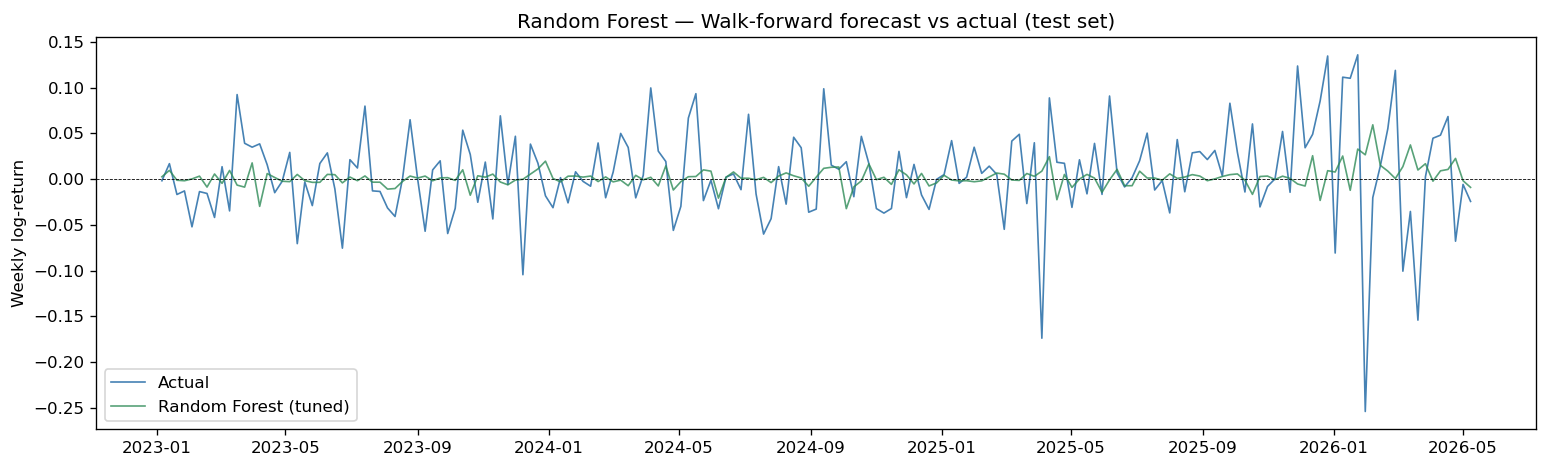

In [27]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_index, y_test,  lw=1, label='Actual',               color='steelblue')
ax.plot(test_index, preds_rf, lw=1, label='Random Forest (tuned)', color='seagreen', alpha=0.8)
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_title('Random Forest — Walk-forward forecast vs actual (test set)')
ax.set_ylabel('Weekly log-return')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Feature importance

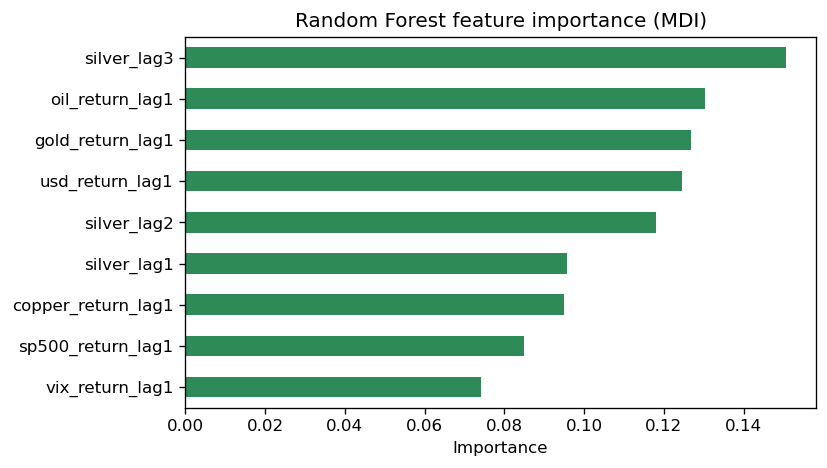

silver_lag3           0.150613
oil_return_lag1       0.130193
gold_return_lag1      0.126692
usd_return_lag1       0.124572
silver_lag2           0.117981
silver_lag1           0.095686
copper_return_lag1    0.095074
sp500_return_lag1     0.085016
vix_return_lag1       0.074172
dtype: float64


In [28]:
X_all = features_all[feature_cols].values
y_all = all_w[TARGET].values
mask  = ~np.isnan(X_all[:n_train]).any(axis=1)

final_model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
final_model.fit(X_all[:n_train][mask], y_all[:n_train][mask])

importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax, color='seagreen')
ax.set_title('Random Forest feature importance (MDI)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False))

## 8. Sentiment comparison

Re-runs the walk-forward adding lagged weekly Reddit and news sentiment as extra features.
Compares DA and WDA with and without sentiment to test whether sentiment adds predictive value.

In [29]:
import os

sent_path = "../../data/processed/daily_sentiment.csv"
if not os.path.exists(sent_path):
    print("daily_sentiment.csv not found — run 03_sentiment.ipynb first.")
else:
    sentiment = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    sent_w = sentiment[["reddit_sentiment", "news_sentiment"]].resample("W-FRI").mean()
    sent_w_lag = sent_w.shift(1)
    all_candidates = {}

    def tune(X_tr_s, y_tr_s, model_cls):
        mask_s = ~np.isnan(X_tr_s).any(axis=1)
        X_tr_s, y_tr_s = X_tr_s[mask_s], y_tr_s[mask_s]
        best_rmse_s, best_params_s = np.inf, {}
        for combo in combos:
            params = dict(zip(keys, combo))
            fold_rmses = []
            for fold_tr, fold_val in tscv.split(X_tr_s):
                m = model_cls(random_state=42, n_jobs=-1, **params)
                m.fit(X_tr_s[fold_tr], y_tr_s[fold_tr])
                preds = m.predict(X_tr_s[fold_val])
                fold_rmses.append(np.sqrt(mean_squared_error(y_tr_s[fold_val], preds)))
            rmse = np.mean(fold_rmses)
            if rmse < best_rmse_s:
                best_rmse_s, best_params_s = rmse, params
        return best_params_s, best_rmse_s

    def run_sentiment(sent_cols, label, features_base, feature_cols_base):
        feats = features_base.copy()
        for col in sent_cols:
            feats[col + "_lag1"] = sent_w_lag[col].reindex(feats.index).ffill()
        fcols = feats.columns.tolist()
        X_tr_s = feats.iloc[:n_train][fcols].values
        y_tr_s = all_w[TARGET].iloc[:n_train].values
        params_s, _ = tune(X_tr_s, y_tr_s, RandomForestRegressor)
        p_exp = walk_forward(all_w, feats, n_train, fcols,            **params_s)
        p_rol = walk_forward(all_w, feats, n_train, fcols, window=100, **params_s)
        print("--- {} ---".format(label))
        evaluate("{} expanding".format(label),      y_test, p_exp)
        evaluate("{} rolling (100w)".format(label), y_test, p_rol)
        all_candidates["{} expanding".format(label)]      = p_exp
        all_candidates["{} rolling (100w)".format(label)] = p_rol

    print("--- No sentiment (baseline) ---")
    evaluate("No sentiment expanding",      y_test, preds_rf_exp)
    evaluate("No sentiment rolling (100w)", y_test, preds_rf_rol)
    all_candidates["No sentiment expanding"]      = preds_rf_exp
    all_candidates["No sentiment rolling (100w)"] = preds_rf_rol
    print()

    print("Tuning and running: Reddit + News...")
    run_sentiment(["reddit_sentiment", "news_sentiment"], "Reddit+News", features_all, feature_cols)
    print()

    print("Tuning and running: Reddit only...")
    run_sentiment(["reddit_sentiment"], "Reddit only", features_all, feature_cols)
    print()

    print("Tuning and running: News only (GDELT)...")
    run_sentiment(["news_sentiment"], "News only", features_all, feature_cols)

--- No sentiment (baseline) ---
No sentiment expanding                    RMSE=0.05349  MAE=0.03754  DA=0.520  WDA=0.495
No sentiment rolling (100w)               RMSE=0.05335  MAE=0.03815  DA=0.486  WDA=0.475

Tuning and running: Reddit + News...
--- Reddit+News ---
Reddit+News expanding                     RMSE=0.05273  MAE=0.03761  DA=0.543  WDA=0.506
Reddit+News rolling (100w)                RMSE=0.05151  MAE=0.03705  DA=0.543  WDA=0.589

Tuning and running: Reddit only...
--- Reddit only ---
Reddit only expanding                     RMSE=0.05335  MAE=0.03755  DA=0.543  WDA=0.525
Reddit only rolling (100w)                RMSE=0.05276  MAE=0.03744  DA=0.486  WDA=0.467

Tuning and running: News only (GDELT)...
--- News only ---
News only expanding                       RMSE=0.05206  MAE=0.03746  DA=0.520  WDA=0.539
News only rolling (100w)                  RMSE=0.05146  MAE=0.03712  DA=0.509  WDA=0.573


## Sub-period robustness: DA and WDA by year

Breaks down the best-performing variant by calendar year to check whether
the result is stable across different market regimes.

In [30]:
# Pick best variant across all candidates collected in the sentiment cell above
def period_metrics(actual_arr, pred_arr, index, periods):
    df = pd.DataFrame({"actual": actual_arr, "pred": pred_arr}, index=index).dropna()
    rows = []
    for label, (start, end) in periods.items():
        sub = df.loc[start:end]
        if len(sub) < 4:
            continue
        correct = np.sign(sub["actual"]) == np.sign(sub["pred"])
        da  = correct.mean()
        wda = (np.abs(sub["actual"]) * correct).sum() / np.abs(sub["actual"]).sum()
        rows.append({"Period": label, "n": len(sub), "DA": da, "WDA": wda})
    return pd.DataFrame(rows).set_index("Period")

PERIODS = {
    "2023  (choppy)":     ("2023", "2023"),
    "2024  (bull start)": ("2024", "2024"),
    "2025  (bull run)":   ("2025", "2025"),
    "2026  (YTD)":        ("2026", "2026"),
    "── Full test ──":    ("2023", "2026"),
}

best_name = max(all_candidates, key=lambda k: np.nanmean(np.sign(y_test) == np.sign(all_candidates[k])))
best_pred = all_candidates[best_name]
print("Best variant by DA:", best_name)
res = period_metrics(y_test, best_pred, test_index, PERIODS)
display(res[["n", "DA", "WDA"]].style
        .format({"n": "{:.0f}", "DA": "{:.3f}", "WDA": "{:.3f}"})
        .background_gradient(cmap="RdYlGn", subset=["DA", "WDA"], vmin=0.4, vmax=0.7))

Best variant by DA: Reddit+News expanding


,n,DA,WDA
Period,,,
2023 (choppy),52,0.519,0.522
2024 (bull start),52,0.596,0.620
2025 (bull run),52,0.538,0.459
2026 (YTD),19,0.474,0.429
── Full test ──,175,0.543,0.506


## Diebold-Mariano test

Tests whether sentiment variants produce statistically significant forecast improvements
over the no-sentiment baseline. H0: equal predictive accuracy (squared error loss).
p < 0.05 = significant improvement.

In [31]:
from scipy import stats as scipy_stats

def diebold_mariano(actual, pred1, pred2, name1='Model 1', name2='Model 2'):
    """DM test, squared error loss. Negative DM stat = pred1 better."""
    mask = ~np.isnan(pred1) & ~np.isnan(pred2) & ~np.isnan(actual)
    actual, pred1, pred2 = actual[mask], pred1[mask], pred2[mask]
    e1 = (actual - pred1) ** 2
    e2 = (actual - pred2) ** 2
    d  = e1 - e2
    n  = len(d)
    d_bar  = np.mean(d)
    gamma0 = np.var(d, ddof=1)
    gamma1 = np.cov(d[:-1], d[1:])[0, 1] if n > 1 else 0
    var_d  = (gamma0 + 2 * gamma1) / n
    if var_d <= 0:
        print(f'{name1} vs {name2}: variance non-positive, skipping')
        return
    dm_stat = d_bar / np.sqrt(var_d)
    p_val   = 2 * (1 - scipy_stats.norm.cdf(abs(dm_stat)))
    sig     = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "(ns)"
    better  = name1 if dm_stat < 0 else name2
    print(f"{name1:<35} vs {name2:<35}  DM={dm_stat:+.3f}  p={p_val:.3f}  {sig}")
    if p_val < 0.05:
        print(f"  -> {better} is significantly more accurate")

print("Diebold-Mariano tests — each variant vs no-sentiment baseline")
print("H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant")
print("-" * 90)

baseline_key = "No sentiment expanding"
baseline_pred = all_candidates[baseline_key]
for name, pred in all_candidates.items():
    if name == baseline_key:
        continue
    diebold_mariano(y_test, baseline_pred, pred, baseline_key, name)

Diebold-Mariano tests — each variant vs no-sentiment baseline
H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant
------------------------------------------------------------------------------------------
No sentiment expanding              vs No sentiment rolling (100w)          DM=+0.328  p=0.743  (ns)
No sentiment expanding              vs Reddit+News expanding                DM=+1.080  p=0.280  (ns)
No sentiment expanding              vs Reddit+News rolling (100w)           DM=+2.003  p=0.045  *
  -> Reddit+News rolling (100w) is significantly more accurate
No sentiment expanding              vs Reddit only expanding                DM=+0.472  p=0.637  (ns)
No sentiment expanding              vs Reddit only rolling (100w)           DM=+1.015  p=0.310  (ns)
No sentiment expanding              vs News only expanding                  DM=+1.498  p=0.134  (ns)
No sentiment expanding              vs News only rolling (100w)             DM=+2.172  p=0.030

## 2026 zoom — actual vs best model

Focuses on the most recent out-of-sample period where silver has been most active.
Uses the best-performing variant selected earlier.

In [ ]:
df26 = pd.DataFrame({"actual": y_test, "pred": best_pred}, index=test_index)
df26 = df26.loc["2026":]

if df26.empty:
    print("No 2026 data in test set yet.")
else:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(df26.index, df26["actual"], color="black",  lw=1.5, marker="o", ms=4, label="Actual")
    ax.plot(df26.index, df26["pred"],   color="#27ae60", lw=1.5, marker="o", ms=4,
            ls="--", label=f"{best_name}")
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(f"2026 — actual vs {best_name} (weekly log-returns)", fontsize=12)
    ax.set_ylabel("Weekly log-return")
    ax.set_xlabel("Week")
    ax.legend()
    plt.tight_layout()
    plt.show()